In [1]:
import numpy as np
import math
from scipy.spatial import Voronoi,voronoi_plot_2d
import random as rnd
import matplotlib.pyplot as plt
from IPython.display import display, HTML,Javascript,clear_output
import time

In [2]:
class SVGPlot:
    def __init__(self, width, height, size):
       
        self.width = width
        self.height = height
        self.size = size
        self.html_s = ""

    def clear(self):
        self.html_s = f'<svg width="{self.width}" height="{self.height}" style="border:1px solid black">'

    def add_circle(self,x_pos,y_pos,color,size= 1.0):
        x_pos = x_pos / self.size
        y_pos = self.size - y_pos
        y_pos = y_pos / self.size
        radius = size / (self.size * 2)
        str_int_x = str(int((x_pos * self.width) + (radius * self.width)))
        str_int_y = str(int((y_pos * self.height) + (radius * self.width)))
        str_int_r = str(int(radius * self.width))
        self.html_s += f'<circle cx="{str_int_x}" cy="{str_int_y}" r="{str_int_r}" fill="{color}"/>'

    def add_rect(self,x_pos,y_pos,color,size=1.0):
        x_pos = x_pos / self.size
        y_pos = self.size - y_pos
        y_pos = y_pos / self.size
        height = size / self.size
        width = size / self.size
        str_int_x = str(int(x_pos * self.width))
        str_int_y = str(int(y_pos * self.height))
        str_int_width = str(int(width * self.width))
        str_int_height = str(int(height * self.height))

        self.html_s += f'<rect x="{str_int_x}" y="{str_int_y}" width="{str_int_width}" height="{str_int_height}" fill="{color}"/>'

    def add_polygon(self,vertices,color):
        if len(vertices) < 3:
            raise ValueError("A polygon must have at least 3 vertices.")
        scaled_vertices = []
        for x, y in vertices:
            scaled_x = (x / self.size) * self.width
            y = self.size - y
            scaled_y = (y / self.size) * self.height
            scaled_vertices.append([scaled_x, scaled_y])
        points_string = ' '.join([f"{x},{y}" for x, y in scaled_vertices])
        self.html_s += f'<polygon points="{points_string}" fill="{color}" stroke="black" stroke-width="0.5"/>'

    def get_canvas(self):
        self.html_s += "</svg>"
        return self.html_s

In [3]:
class PopulationArea:
    def __init__(self,area_id,center,vertices,colour = "rgba(255, 255, 255, 0.0)"):
        self.area_id = area_id
        self.center = center
        self.polygon = vertices
        self.colour = colour
        self.local_population = []

    def point_in_polygon(self,x,y):
        polygon = np.asarray(self.polygon)
        n = len(polygon)
        inside = False
        for i in range(n):
            x1, y1 = polygon[i]
            x2, y2 = polygon[(i + 1) % n]
            
            # Check if edge crosses horizontal ray to the right
            if ((y1 > y) != (y2 > y)) and (x < (x2 - x1) * (y - y1) / (y2 - y1) + x1):
                inside = not inside
        return inside

    def create_population(self,pop_size,population):
        for _ in range(pop_size):
            person = Denizen(self)
            person.assign_pos()
            population.append(person)

    def draw(self,svg,colour=lambda p: "rgb(0,0,0)"):
        svg.add_polygon(self.polygon,self.colour)
        for p in self.local_population:
            x = p.pos[0]
            y = p.pos[1]
            svg.add_rect(x,y,colour(p),0.07)

In [4]:
def generate_age():
    def age_probability(age):
        if age < 0:
            return 0
        
        # Peak at ~38, rise then fall
        peak = 38
        rise = (age / peak) ** 1.5
        fall = np.exp(-0.035 * (age - peak))
        
        return rise * fall
    age = -1
    while age < 0:
        candidate = np.random.uniform(0, 100)
        p = age_probability(candidate)
        max_p = age_probability(38)  # Peak probability
        
        if np.random.rand() < (p / max_p):
            return int(candidate)

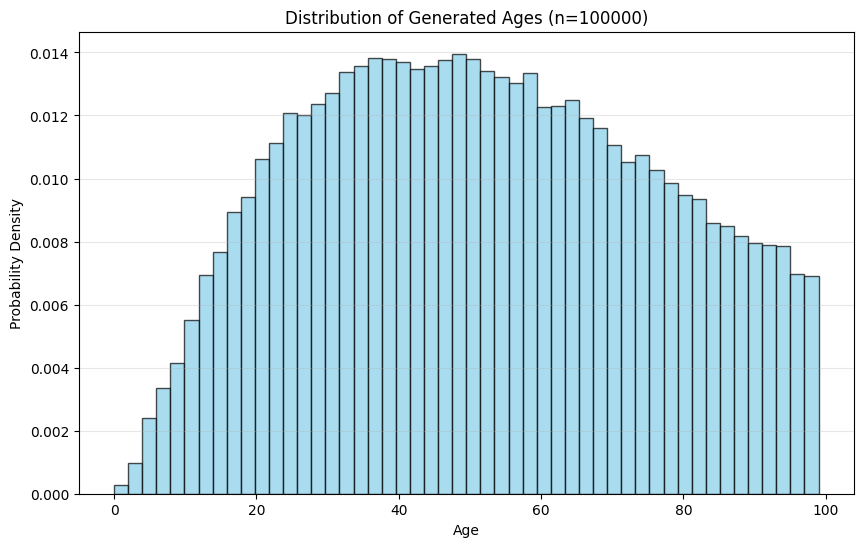

In [5]:
# 1. Generate a large sample of ages
num_samples = 100000
sampled_ages = [generate_age() for _ in range(num_samples)]

# 2. Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(sampled_ages, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True)



plt.title(f"Distribution of Generated Ages (n={num_samples})")
plt.xlabel("Age")
plt.ylabel("Probability Density")

plt.grid(axis='y', alpha=0.3)
plt.show()



In [6]:
def linear_toward_zero():
    magnitude = 1 - math.sqrt(rnd.random())
    return magnitude if rnd.random() < 0.5 else -magnitude
    

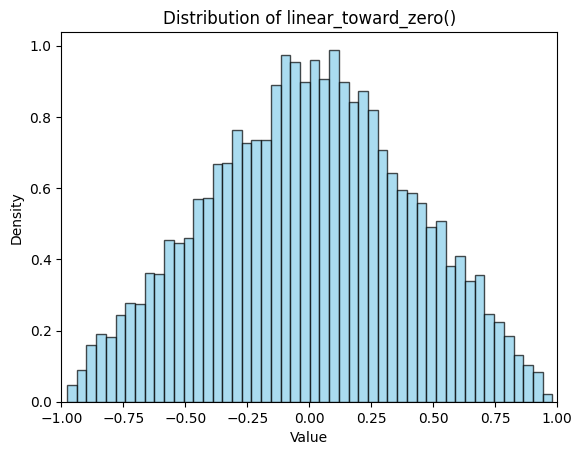

In [7]:
samples = [linear_toward_zero() for _ in range(10000)]

# 3. Plot histogram
plt.hist(samples, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title("Distribution of linear_toward_zero()")
plt.xlabel("Value")
plt.ylabel("Density")
plt.xlim(-1, 1)
plt.show()

In [8]:
def age_migrate_curve(x, start_point=20, end_point=70, decay_rate=None):
    # Convert to array if it isn't already
    x = np.array(x)
    
    # Calculate decay rate
    if decay_rate is None:
        decay_rate = -np.log(0.01) / (end_point - start_point)
    
    # Shift x
    shifted_x = x - start_point
    
    # Calculate exponential
    prob = np.exp(-decay_rate * shifted_x)
    
    # CRITICAL FIX: Set probability to 0 where x < start_point
    prob = np.where(shifted_x < 0, 0, prob)
    
    # Clip to 0-1 just in case
    prob = np.clip(prob, 0, 1)
    
    return prob

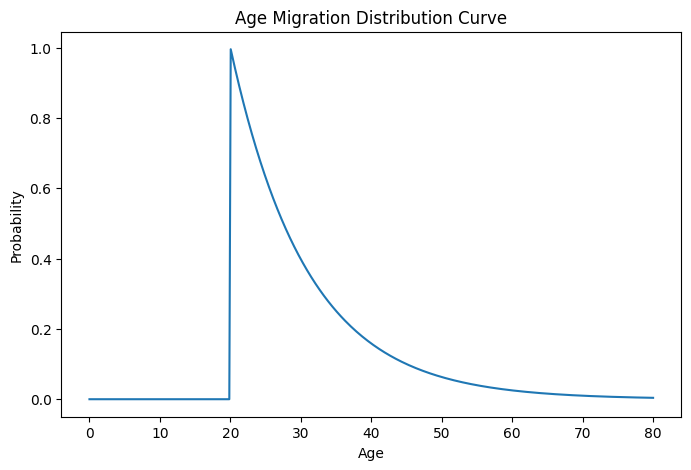

In [9]:
ages = np.linspace(0, 80, 400)
values = age_migrate_curve(ages)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ages, values, label='Migration Probability')
plt.title("Age Migration Distribution Curve")
plt.xlabel("Age")
plt.ylabel("Probability")
plt.show()

In [10]:
class Denizen:
    def __init__(self, area):
        self.area = area
        self.pos = (0,0)
        self.age = generate_age()
        self.moved = False
    
    def assign_pos(self):
        x_vals = [point[0] for point in self.area.polygon]  # x is first element
        y_vals = [point[1] for point in self.area.polygon]  # y is second element
        
        x_min, x_max = min(x_vals), max(x_vals)
        y_min, y_max = min(y_vals), max(y_vals)
        
        while True:
            x = x_min + rnd.random() * (x_max - x_min)
            y = y_min + rnd.random() * (y_max - y_min)
            
            if self.area.point_in_polygon(x, y):
                self.pos = (float(x), float(y))
                self.area.local_population.append(self)
                return

    def migrate(self):
        if rnd.random()<age_migrate_curve(self.age):
            return True


    def __str__(self):
        return f"Vector({self.area.area_id}, {self.pos},{self.age})"

In [11]:
class Simulation:
    def __init__(self):
        self.areas = []
        self.population=[]
        
    def create_areas(self,number_of_areas):
        points = np.random.rand(number_of_areas, 2) * 10  # NUMBER_OF_AREAS rows, 2 columns, scale to 0-10
        vor = Voronoi(points)
        area_id = 0;
        for i in range(len(points)):
            region_idx = vor.point_region[i]
            region = vor.regions[region_idx]
            if region and -1 not in region: #if region` - Ensures the region is not empty -1 not in region` - Filters out unbounded regions
                vertices = vor.vertices[region]
                x_min, y_min = vertices.min(axis=0)  # [min_x, min_y]
                x_max, y_max = vertices.max(axis=0)  # [max_x, max_y]
                if(max([x_max,y_max])<10) and (min([x_min,y_min])>0):
                    self.areas.append(PopulationArea(area_id,points[i],vertices))
                    area_id +=1

    def get_area(self,x,y):
        for area in self.areas:
            if area.point_in_polygon(x,y):
                return True, area
        return False, None
                  
    def create_population(self,local_pop_size):
        for area in self.areas:
            area.create_population(local_pop_size,self.population)
            
    def create_a_population(self,local_pop_size,location = 0):
        self.areas[location].create_population(local_pop_size,self.population)

    def migrate(self):
        for p in self.population:
            if (p.moved)==False and (p.migrate()):
                flag = False
                while flag == False:
                    x = linear_toward_zero()*10
                    y = linear_toward_zero()*10
                    flag, area = self.get_area(x,y)
                    if flag == True:
                        p.pos=(x,y)
                        p.area.local_population.remove(p)
                        p.area= area
                        area.local_population.append(p)
                        p.moved = True  

    def draw(self,svg):
        for area in self.areas:
            area.draw(svg,colour=lambda p: f'rgb(522,{p.age*3},{p.age*3})')

    
        

In [36]:
np.random.seed(42)  # For reproducible results
sim = Simulation()
sim.create_areas(30) # <-- aproximate number of areas. edge areas removed
print(f"{len(sim.areas)} areas created")
sim.create_a_population( int(np.random.normal(loc=1000, scale=20)),11) # <--- number of people in population
print(f"A total population of {len(sim.population)} created ")
# sim.create_population( int(np.random.normal(loc=1000, scale=20))) # populate all the areas
svg = SVGPlot(500, 500, 10)
output_display = display(HTML("<div id='sim-container'>Loading...</div>"), display_id=True)
for t in range (20):
    sim.migrate()
    svg.clear()
    sim.draw(svg)
    new_svg = svg.get_canvas()
    new_svg += f'<p> Iteration: {t} weeks </p>'
    output_display.update(HTML(f"<div id='sim-container'>{new_svg}</div>"))
    time.sleep(0.5) # <----- reduce to speed up simulation

13 areas created
A total population of 970 created 
